# 09c · Same-family scaling sweep (Llama 3.x)

Does the KG lift (MRR$_{KG}$ − MRR$_{no\,KG}$) **grow, shrink, or stay flat** as the model
scales 1B → 405B?  A within-family ladder isolates the *capability* axis — architecture and
training recipe held roughly fixed — which the cross-family GPT/Gemini/Llama comparison can't.

**Ladder & a caveat:** no clean single-generation 5-point ladder exists in Llama, so the rungs
span generations — 1B/3B = Llama 3.2, 8B = 3.1, 70B = 3.3, 405B = 3.1. Generation is carried
through and drawn as the marker shape so the confound is visible; the Llama-3.1 spine (8B→405B)
is the clean within-generation read.

**Memorization confound (the whole game):** bigger/newer models memorise more drug–disease
pairs, inflating the no-KG baseline and *mechanically* shrinking apparent lift. So every figure
splits the KG arm into **covered** (the graph actually contains the pair) vs **all arms pooled**.
All numbers are computed live; the notebook fills in as more rungs finish on HPC.


## Setup


In [ ]:
import os, sys
from IPython.display import display
%matplotlib inline
BASE = os.getcwd()
while not os.path.exists(os.path.join(BASE, 'src', 'scaling_sweep.py')) and os.path.dirname(BASE) != BASE:
    BASE = os.path.dirname(BASE)
sys.path.insert(0, BASE)
from src.scaling_sweep import (load_llama_runs, compute_scaling, fig_lift_vs_size, fig_mrr_vs_size)

RUNS = os.path.join(BASE, 'results', 'tables', '09_llm_runs')
COV  = os.path.join(BASE, 'data', 'gold_standards', 'coverage_annotation_v4.csv')
df = load_llama_runs(RUNS)
print('rungs run so far:', sorted(df.model.unique()))


## Scaling table

Per model: MRR on each arm, and the KG lift (pooled and covered-only) with a 95% **cluster
bootstrap** CI over the 116 diseases — the same unit used elsewhere in the study.


In [ ]:
s = compute_scaling(df, COV)
s[['label','params','gen','mrr_nokg','mrr_kg','mrr_kg_cov',
   'lift','lift_lo','lift_hi','lift_cov','lift_cov_lo','lift_cov_hi','n_dis']].round(3)


## Figures

**1 · KG lift vs model size** — the headline. Pooled (grey) vs covered-arm (green) lift across
the ladder, error bars = 95% cluster bootstrap CI, marker shape = Llama generation. Read the
*covered* line for the capability effect with memorization netted out; if pooled and covered
diverge at the small end, that gap is the empty-arm/memorization artifact, not capability.


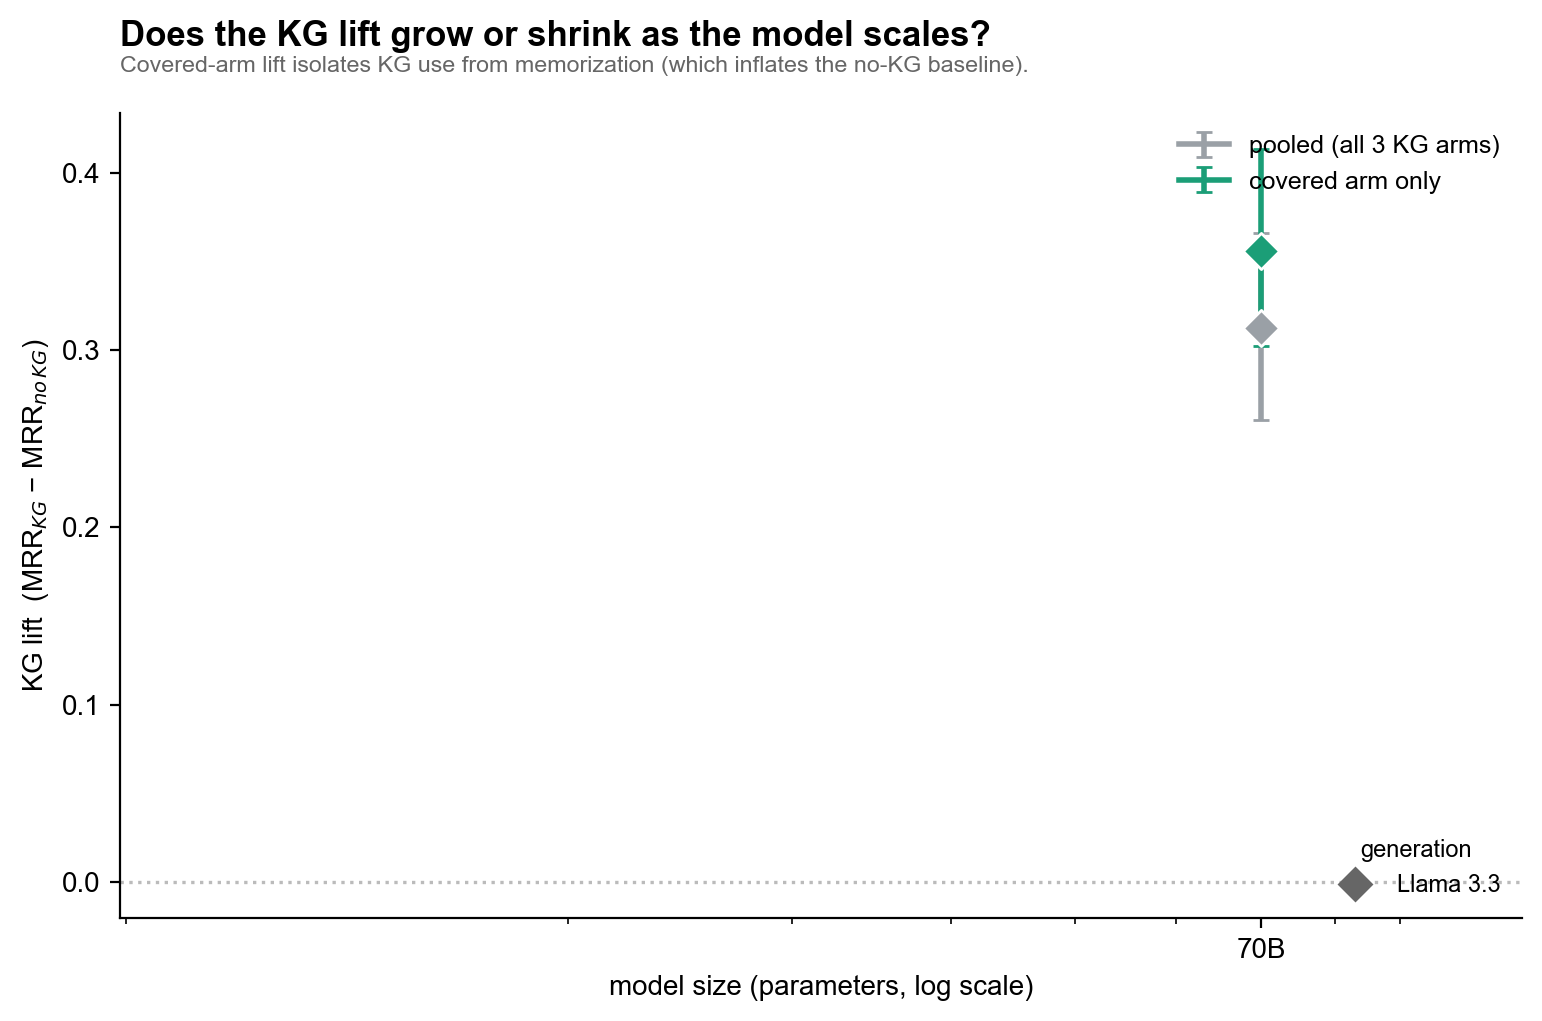

In [ ]:
fig_lift_vs_size(s);


**2 · Where the lift comes from** — no-KG (prior-only) vs KG-arm MRR by size. A **rising no-KG
line** with scale is the memorization signal (bigger models recall more pairs unaided); the gap
to the KG line is the lift.


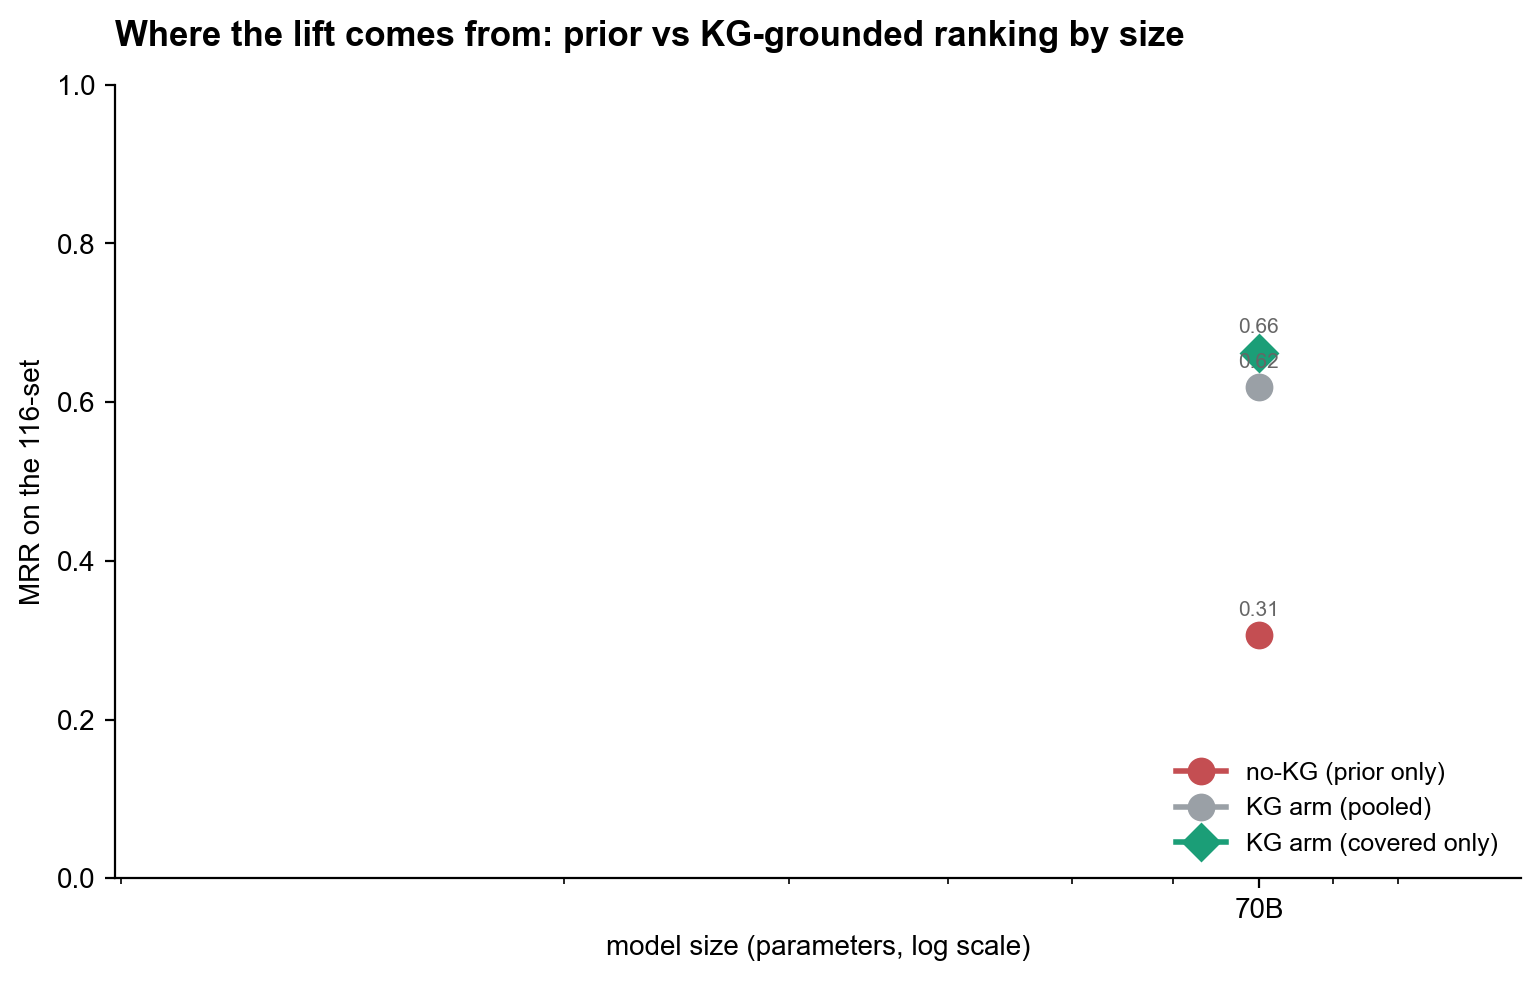

In [ ]:
fig_mrr_vs_size(s);


## How to read the result

- **Lift grows with size** → bigger models exploit the KG *better* (the graph compounds capability).
- **Lift shrinks with size** → capability substitutes for the graph (the 'crutch' story) — but first
  rule out memorization by checking the covered line and the no-KG trend in Figure 2.
- **Lift flat** → KG value is capability-independent — the strongest robustness claim for the method.

Compare the **pooled vs covered** lines: a pooled-only trend that vanishes on the covered line is an
evidence-availability/memorization artifact, not a real capability effect.

*Engine: `src/scaling_sweep.py`. Runs produced by `scripts/hpc/run_llm_ladder.sbatch` (1B/3B/8B/70B)
and `scripts/hpc/run_llm_405b.sbatch` (405B).*
